# Robust regression
- 이상치에 의해 전체 추정치가 왜곡되는 문제가 있을 때
- 잔차의 제곱 대신 절댓값의 합이 최소가 되도록 회귀계수 추정 -> 이상치의 영향력을 줄인다. 
- epsilon이 작을 수록 이상치에 더 강건해진다. 

## Huber Regression : Huber 손실 : MSE + MAE의 종합

In [18]:
# HuberRegressor로 적합하고 예측 하면 원본데이터의 일반적 흐름을 더 잘 나타냄

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error

# 1. 데이터 생성 (이상치 포함)
np.random.seed(42)
X = np.random.normal(0, 1, 80).reshape(-1, 1)
y = 3 * X.squeeze() + np.random.normal(0, 0.5, 80)

# 이상치 추가
X_outliers = np.random.uniform(-3, 3, 10).reshape(-1, 1)
y_outliers = np.random.uniform(-10, 10, 10)
X_all = np.vstack([X, X_outliers])
y_all = np.concatenate([y, y_outliers])

# 2. 모델 학습
linreg = LinearRegression()
linreg.fit(X_all, y_all)

huber = HuberRegressor()
huber.fit(X_all, y_all)

# 3. 예측
X_test = np.linspace(-3, 3, 100).reshape(-1, 1)
y_lin_pred = linreg.predict(X_test)
y_huber_pred = huber.predict(X_test)

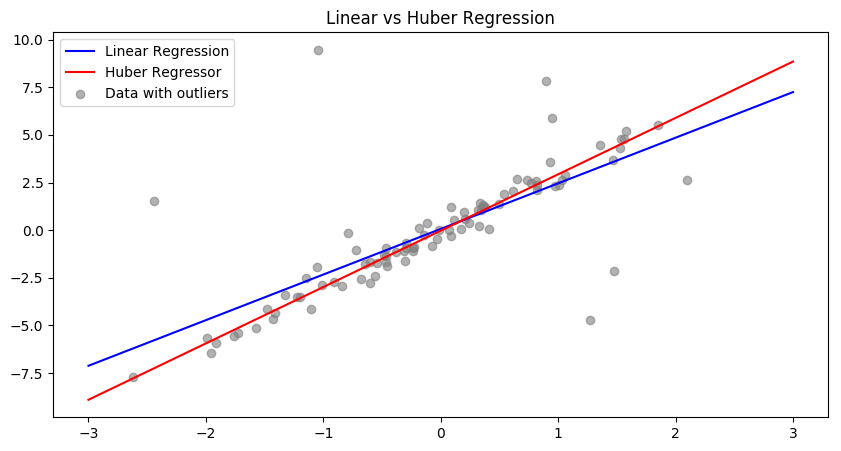

In [19]:
# 4. 시각화
plt.figure(figsize=(10, 5))
plt.scatter(X_all, y_all, color='gray', alpha=0.6, label='Data with outliers')
plt.plot(X_test, y_lin_pred, color='blue', label='Linear Regression')
plt.plot(X_test, y_huber_pred, color='red', label='Huber Regressor')
plt.title('Linear vs Huber Regression')
plt.legend()
plt.show()

In [28]:
# 6. 결과 비교
print(f"LinearRegression Coef: {linreg.coef_[0]:.3f}, Intercept: {linreg.intercept_:.3f}")
print(f"QuantileRegression Coef: {huber.coef_ }, Intercept: {huber.intercept_}")

LinearRegression Coef: 2.394, Intercept: 0.065
QuantileRegression Coef: [2.9585129], Intercept: -0.025407503816333343


In [5]:
# 실제 회귀계수가 3에 가까워야 된다. 
# 이상치가 많을 가능성이 있는 현실 데이터에서는 HuberRegressor를 쓰는 것이 훨씬 안전하고 유리하다. 
# Huber는 선형 회귀와 L1 회귀(Robust한 절댓값 손실)의 장점만 조합한 형태

## Quantile Regression : 평균이 아니라 특정 분위값을 추정하는 모델 
- 중앙값을 추정하는 모델을 만들면 이상치의 영향을 거의 받지 않게 된다. 
- 이분산 데이터도 분위수 회귀 모델링이 가능하다. 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# 1. 데이터 생성
np.random.seed(0)
X = np.linspace(0, 10, 100)
y = 3*X + np.random.normal(0, 2, size=X.shape)

# 이상치 추가
X[::10] = X[::10] + np.random.normal(0, 5, size=(10,))
y[::10] = y[::10] + np.random.normal(20, 10, size=(10,))

X_2d = X.reshape(-1, 1)
X_const = sm.add_constant(X_2d)  # QuantReg는 상수항 필요

# 2. 분위수 회귀 적합 (중앙값, 0.5)
model_qr = sm.QuantReg(y, X_const).fit(q=0.5)

# 3. 선형 회귀 적합
model_lr = LinearRegression().fit(X_2d, y)

# 4. 예측
X_pred = np.linspace(0, 10, 100)
X_pred_2d = X_pred.reshape(-1, 1)
X_pred_const = sm.add_constant(X_pred_2d)

y_qr_pred = model_qr.predict(X_pred_const)
y_lr_pred = model_lr.predict(X_pred_2d)

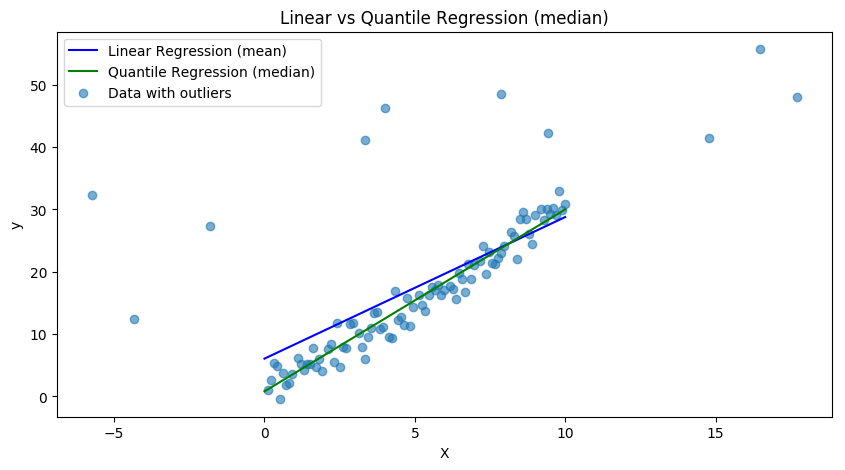

LinearRegression Coef: 2.271, Intercept: 6.067
QuantileRegression Coef: 2.919, Intercept: 0.809


In [7]:
# 5. 시각화
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.6, label='Data with outliers')
plt.plot(X_pred, y_lr_pred, label='Linear Regression (mean)', color='blue')
plt.plot(X_pred, y_qr_pred, label='Quantile Regression (median)', color='green')
plt.title("Linear vs Quantile Regression (median)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# 6. 결과 비교
print(f"LinearRegression Coef: {model_lr.coef_[0]:.3f}, Intercept: {model_lr.intercept_:.3f}")
print(f"QuantileRegression Coef: {model_qr.params[1]:.3f}, Intercept: {model_qr.params[0]:.3f}")

In [12]:
# 실제 회귀계수가 3에 가까워야 한다. 